#  Projeto 1 Inteligência Artificial - Cardio IA
## Integrantes
- Fabio Oliveira da Silva - 10420458
- Matheus Mendonça Lopes - 10443495
- Miguel Piñeiro Coratolo Simões - 10427085
- Patrick Rocha de Andrade - 10410902
- Pedro Cavalcante Ferreira de Andrade - 10408394
- Thaís Ferreira Canguçu - 10403283 

## Informações sobre a base utilizada
A base pode ser encontrada no link:
[Kaggle - UCI Heart Disease Data](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data/data)

O dataset possui 16 colunas, sendo elas:
- id: Identificação da linha
- age: Idade do paciente       
- sex: Sexo do paciente        
- dataset: Onde a coleta dos dados foram realizadas    
- cp: Tipo de dor no peito informada        
- trestbps: Pressão do sangue em repouso (mm Hg)
- chol: Nível de colesterol (mg/dl)        
- fbs: Flag para glicemia em jejum > 120 mg/dl (True para > 120 mg/dl)          
- restecg: Resultado do ECG    
- thalch: Frequência cardíaca máxima atingida    
- exang: Dores durante exercício físico (True/False)     
- oldpeak: Depressão do segmento ST no eletrocardiograma (ECG) provocada pelo exercício   
- slope: Inclinação do segmento ST durante o pico do exercício     
- ca: Número de grandes vasos sanguíneos observados com contraste durante uma fluoroscopia/coronariografia        
- thal: Resultado da cintilografia de perfusão miocárdica (mede talassemia)      
- num: Estágios de doença cardíaca (0: sem doença, 1-4: Estágios da doença, sendo 4 o pior estado) 

O objetivo do projeto não é diagnosticar uma doença em específico, uma vez que o dataset não possui a descrição da doença constatada em cada linha, logo, o objetivo é classificar se há presença de doença ou não e seu estágio (definido na coluna 'num').   


## Bibliotecas

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Estatísticas da base

In [3]:
# Carrega o dataset
df = pd.read_csv("heart_disease_uci.csv")

# Quantidade de linhas e colunas
print("Dimensões da base de dados:")
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

print("\n")


print("Sample de dados:")
display(df.head())

print("\n")

# Tipos das colunas
print("Tipos das colunas:")
display(df.dtypes)

print("\n")

# Valores ausentes
print("Valores ausentes por coluna:")
display(df.isnull().sum())

print("\n")

# Estatísticas das variáveis numéricas
print("Estatísticas das variáveis numéricas:")
display(df.describe())

Dimensões da base de dados:
Linhas: 920
Colunas: 16


Sample de dados:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0




Tipos das colunas:


id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object



Valores ausentes por coluna:


id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64



Estatísticas das variáveis numéricas:


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## Distribuição de Dados da Base
Histograma e percentuais da base.

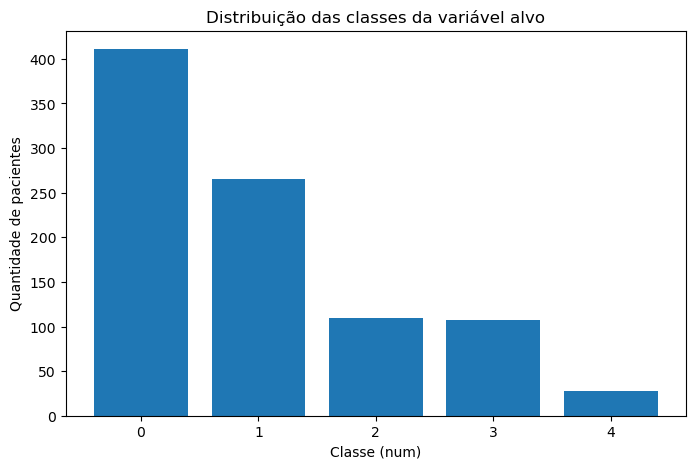

Distribuição da variável 'num':


num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64



Percentual de cada classe:


num
0    44.67
1    28.80
2    11.85
3    11.63
4     3.04
Name: proportion, dtype: float64




sex:
sex
Male      726
Female    194
Name: count, dtype: int64

dataset:
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

cp:
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

fbs:
fbs
False    692
True     138
NaN       90
Name: count, dtype: int64

restecg:
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
NaN                   2
Name: count, dtype: int64

exang:
exang
False    528
True     337
NaN       55
Name: count, dtype: int64

slope:
slope
flat           345
NaN            309
upsloping      203
downsloping     63
Name: count, dtype: int64

thal:
thal
NaN                  486
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64


In [ ]:
# Conta quantos exemplos existem em cada classe
contagem = df["num"].value_counts().sort_index()

# Cria o gráfico
plt.figure(figsize=(8, 5))
plt.bar(contagem.index.astype(str), contagem.values)

plt.xlabel("Classe (num)")
plt.ylabel("Quantidade de pacientes")
plt.title("Distribuição das classes da variável alvo")

plt.show()

# Distribuição da variável alvo
print("Distribuição da variável 'num':")
display(df["num"].value_counts().sort_index())

print("\n")

# Percentual de cada classe
print("Percentual de cada classe:")
display(df["num"].value_counts(normalize=True).sort_index().mul(100).round(2))

print("\n")

# Valores existentes nas principais variáveis categóricas
colunas_categoricas = [
    "sex",
    "dataset",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
]

for coluna in colunas_categoricas:
    print(f"\n{coluna}:")
    print(df[coluna].value_counts(dropna=False))

## Tratamento de base e definição das variáveis para o treinamento

In [ ]:
# Colunas que serão utilizadas como entrada para o modelo
entradas = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalch",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal"
]

# X = dados usados para fazer a previsão
X = df[entradas].copy()

# y = resposta que queremos que o modelo aprenda a prever
y = df["num"].copy()

# Divide os dados em treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2, # 80% treinamento e 20% teste
    random_state=42,
    stratify=y # Mantém a mesma proporção de classes na divisão treino/teste
)

print("Dados de treino:")
print("X_treino:", X_treino.shape)
print("y_treino:", y_treino.shape)

print("\nDados de teste:")
print("X_teste:", X_teste.shape)
print("y_teste:", y_teste.shape)

Dados de treino:
X_treino: (736, 13)
y_treino: (736,)

Dados de teste:
X_teste: (184, 13)
y_teste: (184,)


## Separação de dados numéricos e categóricos e Pré-processamento
Para valores numéricos ausentes, colocamos a mediana daquela coluna no dado faltante. Para variáveis categóricas, substituímos pelo valor que mais aparece e depois convertemos os valores do texto em colunas numéricas usando o OneHotEncoder.

In [14]:
# Variáveis numéricas
entradas_numericas = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca"
]

# Variáveis categóricas
entradas_categoricas = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
]

# Pipeline para variáveis numéricas
pipeline_numerico = Pipeline([
    # Preenche valores ausentes com a mediana da coluna
    ("imputer", SimpleImputer(strategy="median"))
])

# Pipeline para variáveis categóricas
pipeline_categorico = Pipeline([
    # Preenche valores ausentes com o valor mais frequente
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # Converte categorias de texto em colunas numéricas
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Junta os dois pipelines
preprocessamento = ColumnTransformer([
    ("numerico", pipeline_numerico, entradas_numericas),
    ("categorico", pipeline_categorico, entradas_categoricas)
])

## Treinamento do Modelo (Random Forest)
Utilizamos o Random Forest por ser particularmente eficiente em algoritmos de classificação de várias classes, o que se encaixa no nosso objetivo de classificar entre 0 e 4.

In [29]:
# Cria o modelo
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
)

# Junta o pré-processamento com o modelo
pipeline = Pipeline([
    ("preprocessamento", preprocessamento),
    ("modelo", modelo)
])

# Treina o modelo
pipeline.fit(X_treino, y_treino)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


## Validação do Modelo

Acurácia: 57.07%


Classificação:
              precision    recall  f1-score   support

           0       0.78      0.87      0.82        82
           1       0.52      0.58      0.55        53
           2       0.00      0.00      0.00        22
           3       0.14      0.14      0.14        21
           4       0.00      0.00      0.00         6

    accuracy                           0.57       184
   macro avg       0.29      0.32      0.30       184
weighted avg       0.51      0.57      0.54       184





c:\Users\fabio\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\fabio\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\fabio\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


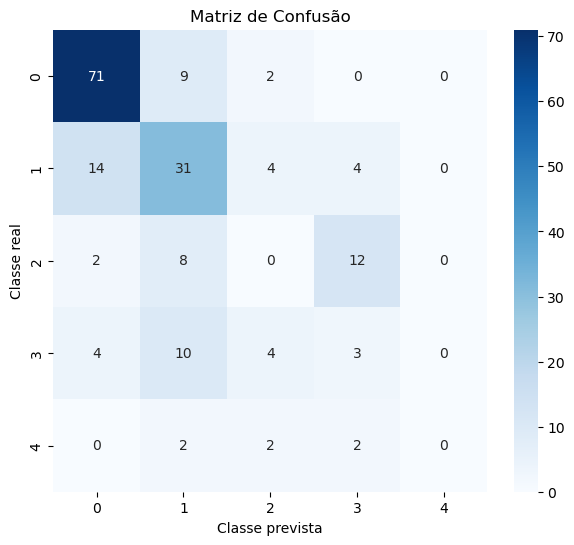

In [30]:
# Faz as previsões usando os dados de teste
y_prev = pipeline.predict(X_teste)

# Pontuação de Acurácia
acuracia = accuracy_score(y_teste, y_prev)

print(f"Acurácia: {acuracia:.2%}")

print("\n")

# Precisão, sensibilidade e f1-score
print("Classificação:")
print(classification_report(y_teste, y_prev))

print('\n')

# Matriz de confusão
matriz = confusion_matrix(y_teste, y_prev)

plt.figure(figsize=(7, 6))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.title("Matriz de Confusão")

plt.show()

## Treinamento de Modelo (Árvore de Decisão)

In [28]:
# Cria o modelo
modelo_arvore = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

# Junta o pré-processamento com o modelo
pipeline_arvore = Pipeline([
    ("preprocessamento", preprocessamento),
    ("modelo", modelo_arvore)
])

# Treina o modelo
pipeline_arvore.fit(X_treino, y_treino)

print("Árvore de decisão treinada com sucesso!")

Árvore de decisão treinada com sucesso!


## Validação da Árvore de Decisão

Acurácia: 47.83%

Classificação:
              precision    recall  f1-score   support

           0       0.71      0.66      0.68        82
           1       0.40      0.43      0.42        53
           2       0.36      0.23      0.28        22
           3       0.17      0.24      0.20        21
           4       0.14      0.17      0.15         6

    accuracy                           0.48       184
   macro avg       0.36      0.34      0.35       184
weighted avg       0.50      0.48      0.49       184



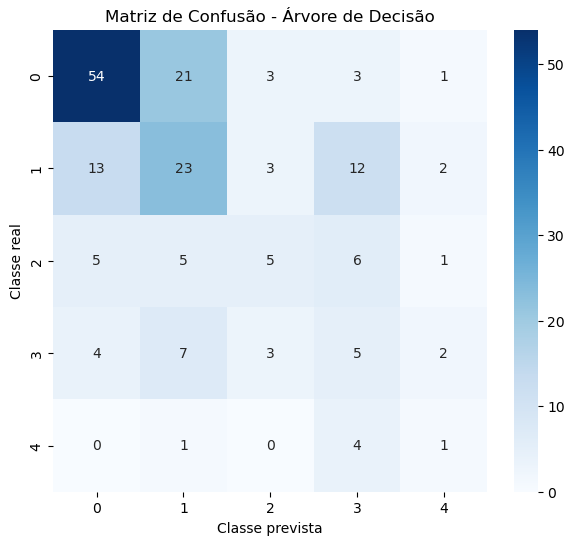

In [31]:
# Previsões
y_prev_arvore = pipeline_arvore.predict(X_teste)

# Acurácia
accuracy_arvore = accuracy_score(y_teste, y_prev_arvore)

print(f"Acurácia: {accuracy_arvore:.2%}")

print("\nClassificação:")
print(classification_report(y_teste, y_prev_arvore))

# Matriz de confusão
matriz_arvore = confusion_matrix(y_teste, y_prev_arvore)

plt.figure(figsize=(7, 6))

sns.heatmap(
    matriz_arvore,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.title("Matriz de Confusão - Árvore de Decisão")

plt.show()

## Célula para entradas do usuário (Testes)
O Random Forest se mostrou particularmente bom em prever quando não há doença: 0, mas mostrou dificuldade na classificação de estágios de doeça a partir do estado 2. A árvore de decisão se mostrou um pouco pior nesse sentido.

Legenda dos resultados:
- 0: Saudável
- 1 a 4: Estágios da doença, sendo 1 mais leve e 4 mais avançado.

In [32]:
# Dados de um paciente para teste
paciente = {
    "age": 55,
    "sex": "Male",
    "cp": "asymptomatic",
    "trestbps": 140,
    "chol": 250,
    "fbs": False,
    "restecg": "normal",
    "thalch": 150,
    "exang": False,
    "oldpeak": 1.5,
    "slope": "flat",
    "ca": 0,
    "thal": "normal"
}

# Transforma os dados em DataFrame
paciente_df = pd.DataFrame([paciente])

# Previsão da Random Forest
previsao_rf = pipeline.predict(paciente_df)[0]

# Previsão da Árvore de Decisão
previsao_arvore = pipeline_arvore.predict(paciente_df)[0]

print("Dados do paciente:")
display(paciente_df)

print("\nResultados:")
print(f"Random Forest:       classe {previsao_rf}")
print(f"Árvore de Decisão:   classe {previsao_arvore}")

Dados do paciente:


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,55,Male,asymptomatic,140,250,False,normal,150,False,1.5,flat,0,normal



Resultados:
Random Forest:       classe 1
Árvore de Decisão:   classe 1
